In [1]:
from datetime import datetime
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import pickle
from datetime import datetime
import os
from pathlib import Path
import fsspec
from cycler import cycler

import re
pd.set_option('display.max_columns', None)
sys.path.insert(0, os.path.abspath('../..'))
import repo_paths  # noqa: F401
%load_ext autoreload
%autoreload 2
from loading_runs import load_results_from_pickle, compute_rowwise_metrics

In [2]:
pickles = load_results_from_pickle(folder='ICML_experiments/synthetic_val_losses',
                                        time_threshold='25_09_03_12_00_00',
                                        keep_run_type=None,
                                   pct_sig_calc=False,
                                          is_output=False
                                        )

# Rename the remaining models
rename_dict = {
    'hide_and_seek': 'Hide&Seek',
    'l2x': 'L2X',
    'lime': 'LIME',
    'invase': 'INVASE',
    'shap_xgboost':'SHAP',
    'lasso':"LASSO",
    'random_forest':"RForest",
    'realx':'REAL-x'
}

temp = pickles.copy()#.drop(['run_type','time_run'])
temp['run_id'] = temp.apply(lambda x: str(x['time_run']) + '_' + str(x['run_type']),axis=1)
# temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)
temp['model'] = temp['run_type'].str.extract(r'm=(.*?)_e=', expand=False)
temp['model'] = temp['model'].replace(rename_dict)
temp['syn'] = temp['syn'].str.extract(r'Syn(\d+)', expand=False).astype(int)

cols_to_num = ['syn', 'TPR_mean', 'FDR_mean', 'TPR_std', 'FDR_std', 'f1', 'accuracy',
       'roc_auc', 'batch_size', 'hide_hidden_dim',
       'seek_hidden_dim', 'hide_num_hidden_layers', 'seek_num_hidden_layers',
       'epochs', 'lmbda', 'seed', 'num_important_features',
       'lmbda_exponent', 'num_syn_features', 'train_N',
       ]

for col in cols_to_num:
    temp[col] = pd.to_numeric(temp[col])

In [3]:
temp[['lmbda','lmbda_exponent']].value_counts()

lmbda  lmbda_exponent
0.01   0.0               1
       0.5               1
       1.0               1
       2.0               1
       3.0               1
0.05   0.0               1
       0.5               1
       1.0               1
       2.0               1
       3.0               1
0.10   0.0               1
       0.5               1
       1.0               1
       2.0               1
       3.0               1
0.20   0.0               1
       0.5               1
       1.0               1
       2.0               1
       3.0               1
0.30   0.0               1
       0.5               1
       1.0               1
       2.0               1
       3.0               1
0.40   0.0               1
       0.5               1
       1.0               1
       2.0               1
       3.0               1
dtype: int64

False


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


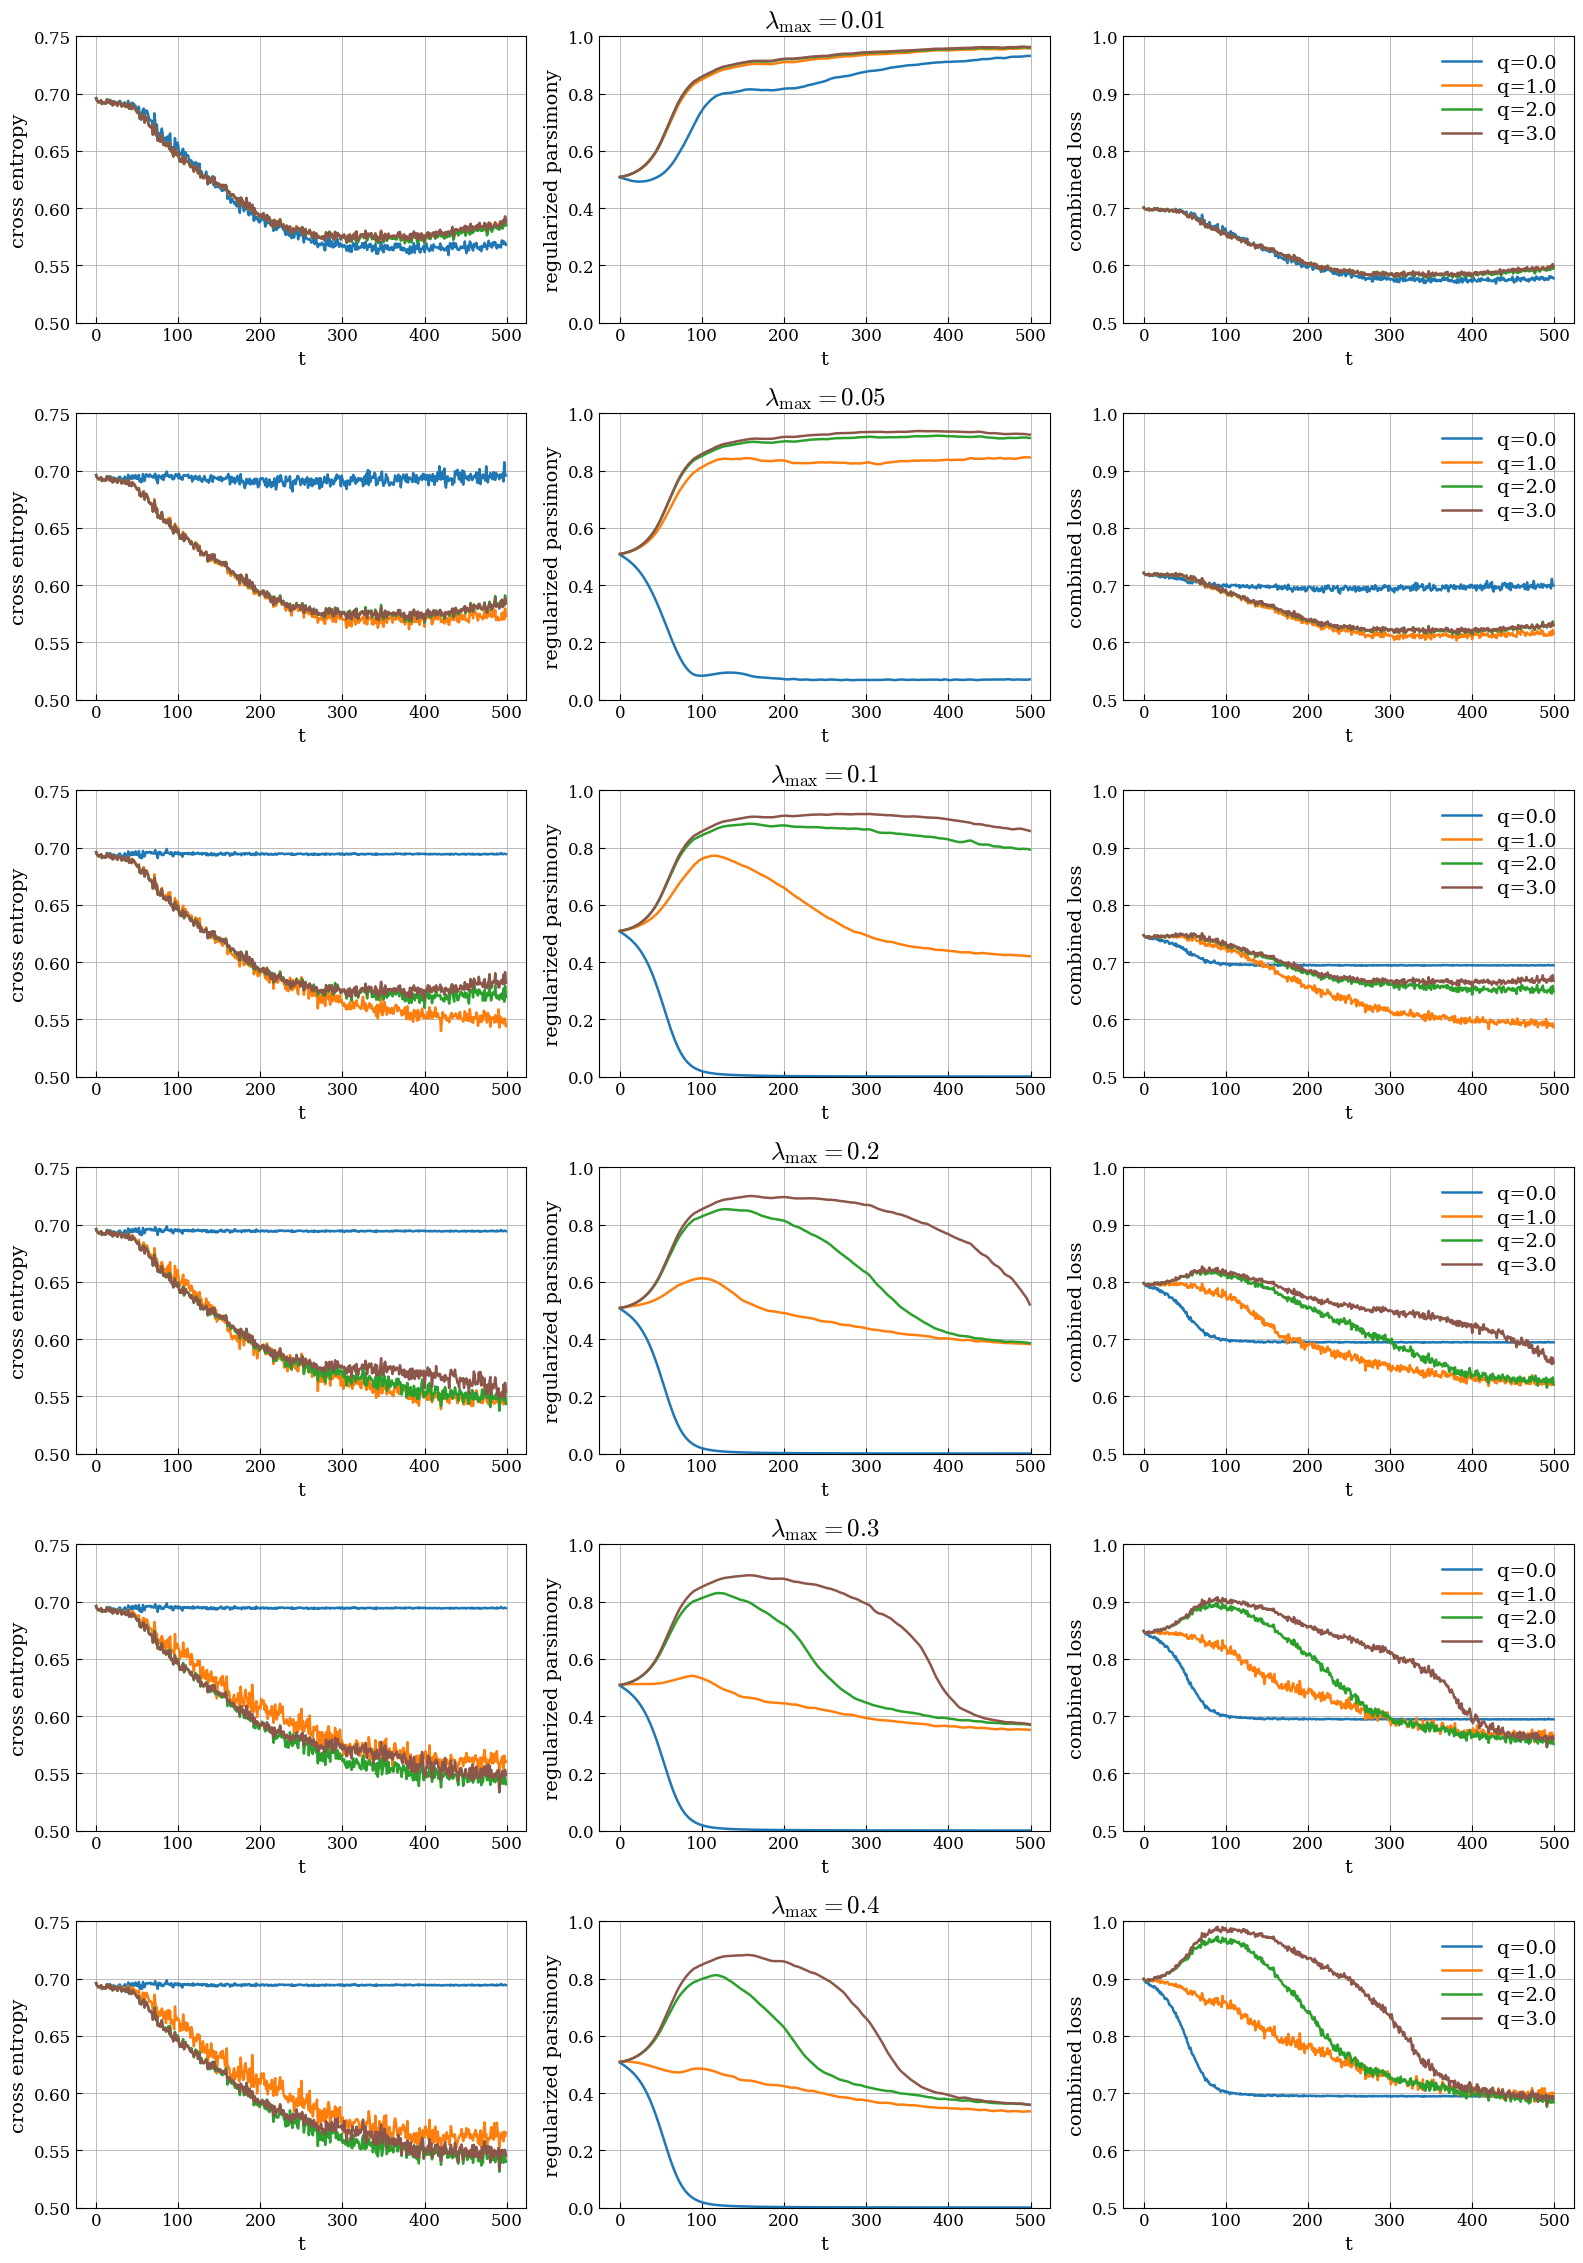

In [4]:
df = temp.copy().query('lmbda_exponent != 0.5') # & lmbda != 0.01

save_path = os.path.join(os.path.abspath('..'), 'figures', 'val_losses_multiple_scenarios.pdf') 
save_path = os.path.expanduser(save_path)

mpl.rcParams['axes.prop_cycle'] = cycler(color=[
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#8c564b',  # brown (instead of red)
])

# ---------------- ICML-style font + sizing ----------------
mpl.rcParams.update({
    # LaTeX-like fonts (portable; no usetex needed)
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",

    # Font sizes
    "font.size": 12,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 14,

    # Line / marker styling
    "lines.linewidth": 1.8,
    "lines.markersize": 5,

    # Axes/grid styling
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.6,

    # PDF export: keep text editable
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 300,
})

# --- 1) Explode losses_on_val into a long dataframe: one row per (experiment, epoch) ---
def epoch_dict_to_long(epoch_dict, exp_id):
    """
    epoch_dict: dict like {0:{...}, 1:{...}, ...}
    exp_id: identifier for the experiment (e.g., df.index value)
    """
    if not isinstance(epoch_dict, dict) or len(epoch_dict) == 0:
        return pd.DataFrame()

    rows = []
    for ep, metrics in epoch_dict.items():
        try:
            ep = int(ep)
        except Exception:
            continue
        if not isinstance(metrics, dict):
            continue

        rows.append({
            "exp_id": exp_id,
            "epoch": ep,
            "val_ce_loss": metrics.get("val_ce_loss", np.nan),
            "val_mask_mean_size": metrics.get("val_mask_mean_size", np.nan),
            "lmbda": metrics.get("lmbda", np.nan),
            "lmbda_exponent": metrics.get("lmbda_exponent", np.nan),
        })

    out = pd.DataFrame(rows)
    return out.sort_values("epoch")

long_df = pd.concat(
    [epoch_dict_to_long(d, exp_id=i) for i, d in zip(df.index, df["losses_on_val"])],
    ignore_index=True
)

# --- 2) Combined objective: val_ce_loss + lmbda * val_mask_mean_size ---
long_df["combined"] = long_df["val_ce_loss"] + long_df["lmbda"] * long_df["val_mask_mean_size"]

# Add roc_auc from df (constant per experiment)
len_before = len(long_df)
long_df = long_df.merge(df[["lmbda", "lmbda_exponent", "roc_auc"]], on=["lmbda", "lmbda_exponent"], how="left")
assert len_before == len(long_df)

# --- 3) n x 3 subplots: each ROW is a different lmbda; 3 COLS are the three metrics ---
metrics = [
    ("val_ce_loss", "cross entropy"),
    ("val_mask_mean_size", "regularized parsimony"),
    # ("combined", r"cross entropy + $\lambda_{t} \cdot$ mask mean size"),
    ("combined", r"combined loss"),
]

lambdas = sorted(long_df["lmbda"].dropna().unique().tolist())
if long_df["lmbda"].isna().any():
    lambdas.append(np.nan)

single_lambda = (len(lambdas) == 1)

n = len(lambdas)

if single_lambda:
    # 3 rows, 1 column (stacked vertically), but we want to index as [0, j]
    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(4, 3.8 * 3),
        sharex=False
    )
    axes = np.asarray(axes).reshape(1, 3)   # shape (1, 3)
else:
    # n rows, 3 columns (grid)
    fig, axes = plt.subplots(
        nrows=n,
        ncols=3,
        figsize=(16, 3.8 * n),
        sharex=False
    )
    axes = np.asarray(axes)
    if n == 1:
        axes = axes.reshape(1, 3)           # shape (1, 3)

col_ylims = {
    "val_ce_loss": (0.5, 0.75),
    "val_mask_mean_size": (0.0, 1.0),
    "combined": (0.5, 1.0),
}

for i, lam in enumerate(lambdas):

    if pd.isna(lam):
        df_lam = long_df[long_df["lmbda"].isna()].copy()
        lam_title = rf"$\lambda_{{\max}} = \mathrm{{NaN}}$"
    else:
        df_lam = long_df[long_df["lmbda"] == lam].copy()
        lam_title = rf"$\lambda_{{\max}} = {lam}$"
        # lam_title = f""

    # Build ONE legend entry per experiment for this lambda row (p + roc_auc)
    exp_meta = (
        df_lam.groupby("exp_id", as_index=True)
              .agg(p=("lmbda_exponent", "first"),
                   roc_auc=("roc_auc", "first"))
    )

    # Sort legend entries by p (optional but usually nicer)
    exp_meta = exp_meta.sort_values("p")

    label_by_exp = {}
    for exp_id, row in exp_meta.iterrows():
        p_val = row["p"]
        roc_val = row["roc_auc"]
        p_str = "NaN" if pd.isna(p_val) else str(p_val)
        roc_str = "NaN" if pd.isna(roc_val) else f"{roc_val:.3f}"
        label_by_exp[exp_id] = f"q={p_str}" #\nroc_auc={roc_str}

    for j, (ycol, ylabel) in enumerate(metrics):
        ax = axes[i, j]

        # Put the lambda title on the middle plot only
        if j == 1:
            ax.set_title(lam_title, fontweight="bold")

        # Plot each experiment as its own line.
        # Only attach labels on the rightmost subplot -> one legend per row.

        ordered_exp_ids = exp_meta.index.tolist()  # exp_meta is already sorted by p

        for exp_id in ordered_exp_ids:
            sub_run = df_lam[df_lam["exp_id"] == exp_id].sort_values("epoch")

            this_label = label_by_exp.get(exp_id, str(exp_id)) if j == 2 else None

            ax.plot(
                sub_run["epoch"].to_numpy(),
                sub_run[ycol].to_numpy(),
                label=this_label
            )

        ax.set_xlabel("t")
        ax.set_ylabel(ylabel)

        ax.set_ylim(*col_ylims[ycol])

        # Grid + tick styling (paper-friendly)
        ax.grid(True)
        ax.tick_params(direction="in", length=4, width=0.8)

        if (j == 2 and ~single_lambda) or (j == 1 and single_lambda):
            ax.legend(
                loc="best",
                # bbox_to_anchor=(0.5, 0.8),
                frameon=False,
                handlelength=2.0,
                labelspacing=0.3
            )

print(single_lambda)
plt.tight_layout()
plt.savefig(save_path, format='pdf', bbox_inches='tight')
plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


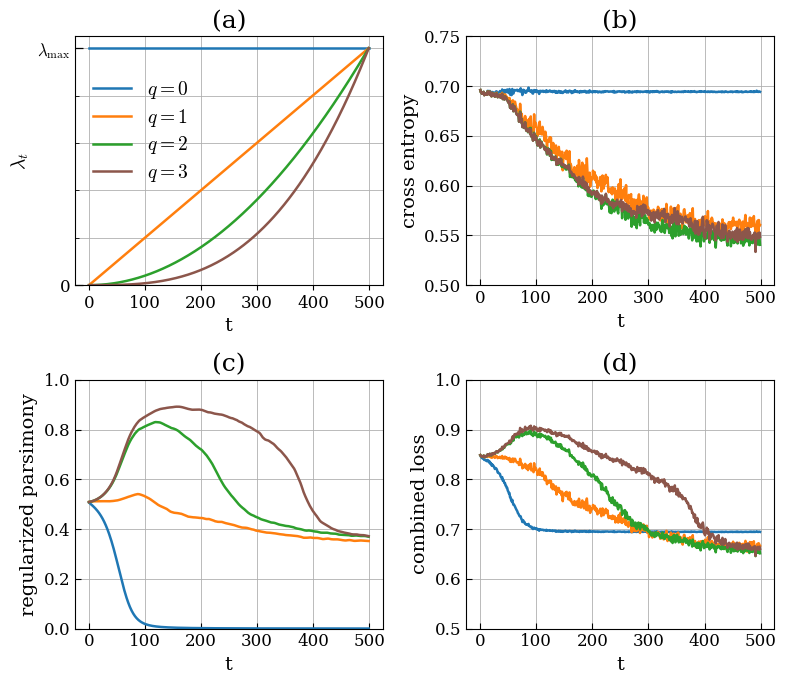

In [37]:
df = temp.copy().query('lmbda_exponent != 0.5 & lmbda == 0.3')

save_path = os.path.join(os.path.abspath('..'), 'figures', 'val_losses_lambda03.pdf') 
save_path = os.path.expanduser(save_path)

mpl.rcParams['axes.prop_cycle'] = cycler(color=[
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#8c564b',  # brown (instead of red)
])

# ---------------- ICML-style font + sizing ----------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 14,
    "lines.linewidth": 1.8,
    "lines.markersize": 5,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 300,
})

# --- 1) Explode losses_on_val into a long dataframe: one row per (experiment, epoch) ---
def epoch_dict_to_long(epoch_dict, exp_id):
    if not isinstance(epoch_dict, dict) or len(epoch_dict) == 0:
        return pd.DataFrame()

    rows = []
    for ep, metrics in epoch_dict.items():
        try:
            ep = int(ep)
        except Exception:
            continue
        if not isinstance(metrics, dict):
            continue

        rows.append({
            "exp_id": exp_id,
            "epoch": ep,
            "val_ce_loss": metrics.get("val_ce_loss", np.nan),
            "val_mask_mean_size": metrics.get("val_mask_mean_size", np.nan),
            "lmbda": metrics.get("lmbda", np.nan),
            "lmbda_exponent": metrics.get("lmbda_exponent", np.nan),
        })

    return pd.DataFrame(rows).sort_values("epoch")

long_df = pd.concat(
    [epoch_dict_to_long(d, exp_id=i) for i, d in zip(df.index, df["losses_on_val"])],
    ignore_index=True
)

# --- 2) Combined objective: val_ce_loss + lmbda * val_mask_mean_size ---
long_df["combined"] = long_df["val_ce_loss"] + long_df["lmbda"] * long_df["val_mask_mean_size"]

# Add roc_auc from df (constant per experiment)
len_before = len(long_df)
long_df = long_df.merge(df[["lmbda", "lmbda_exponent", "roc_auc"]],
                        on=["lmbda", "lmbda_exponent"],
                        how="left")
assert len_before == len(long_df)

# ---- This script assumes a SINGLE lambda ----
lambdas = sorted(long_df["lmbda"].dropna().unique().tolist())
if long_df["lmbda"].isna().any():
    lambdas.append(np.nan)

if len(lambdas) != 1:
    raise ValueError(f"Expected exactly 1 lambda for the 2x2 single-lambda figure, found {len(lambdas)}: {lambdas}")

lam = lambdas[0]
df_lam = long_df[long_df["lmbda"].isna()].copy() if pd.isna(lam) else long_df[long_df["lmbda"] == lam].copy()

# Legend labels (p only), ordered by p
exp_meta = (
    df_lam.groupby("exp_id", as_index=True)
          .agg(p=("lmbda_exponent", "first"),
               roc_auc=("roc_auc", "first"))
).sort_values("p", na_position="last")

ordered_exp_ids = exp_meta.index.tolist()

label_by_exp = {}
for exp_id, row in exp_meta.iterrows():
    p_val = row["p"]
    p_str = "NaN" if pd.isna(p_val) else str(p_val)
    label_by_exp[exp_id] = f"p={p_str}"

# y-lims
col_ylims = {
    "val_ce_loss": (0.5, 0.75),
    "val_mask_mean_size": (0.0, 1.0),
    "combined": (0.5, 1.0),
}

# ---- 2x2 figure ----
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 7), sharex=False)
axs = np.asarray(axs)

# (0,0): lambda_t schedules
ax00 = axs[0, 0]
t = np.arange(0, 500)  # 0..499
base = 0.3
den = 499.0
for p in [0, 1, 2, 3]:
    lam_t = base * (t / den) ** p
    ax00.plot(t, lam_t, label=rf"$q={p}$")

ax00.set_xlabel("t")
ax00.set_ylabel(r"$\lambda_t$")

# ---- y-axis: major ticks only at 0 and lambda_max, minor ticks every 1/5 ----
lambda_max = 0.3
ax00.set_ylim(0, lambda_max * 1.05)

# Major ticks (labeled)
ax00.set_yticks([0.0, lambda_max])
ax00.set_yticklabels(["0", r"$\lambda_{\max}$"])

# Minor ticks (unlabeled)
minor_ticks = np.linspace(0, lambda_max, 6)  # 0, 1/5, ..., lambda_max
ax00.set_yticks(minor_ticks, minor=True)

ax00.tick_params(axis="y", which="major", direction="in", length=6, width=0.9)
ax00.tick_params(axis="y", which="minor", direction="in", length=3, width=0.6, labelsize=0)

ax00.grid(True, which="minor", axis="y")
ax00.grid(True, which="major", axis="y")
ax00.grid(True, which="major", axis="x")


# (0,1): cross entropy
ax01 = axs[0, 1]
for exp_id in ordered_exp_ids:
    sub_run = df_lam[df_lam["exp_id"] == exp_id].sort_values("epoch")
    ax01.plot(sub_run["epoch"].to_numpy(), sub_run["val_ce_loss"].to_numpy())
ax01.set_xlabel("t")
ax01.set_ylabel("cross entropy")
ax01.set_ylim(*col_ylims["val_ce_loss"])
ax01.grid(True)
ax01.tick_params(direction="in", length=4, width=0.8)

# (1,0): mask mean size
ax10 = axs[1, 0]
for exp_id in ordered_exp_ids:
    sub_run = df_lam[df_lam["exp_id"] == exp_id].sort_values("epoch")
    ax10.plot(sub_run["epoch"].to_numpy(), sub_run["val_mask_mean_size"].to_numpy())
ax10.set_xlabel("t")
ax10.set_ylabel("regularized parsimony")
ax10.set_ylim(*col_ylims["val_mask_mean_size"])
ax10.grid(True)
ax10.tick_params(direction="in", length=4, width=0.8)

# (1,1): combined loss + legend INSIDE this plot
ax11 = axs[1, 1]
for exp_id in ordered_exp_ids:
    sub_run = df_lam[df_lam["exp_id"] == exp_id].sort_values("epoch")
    ax11.plot(
        sub_run["epoch"].to_numpy(),
        sub_run["combined"].to_numpy(),
        label=label_by_exp.get(exp_id, str(exp_id))
    )
ax11.set_xlabel("t")
ax11.set_ylabel("combined loss")
ax11.set_ylim(*col_ylims["combined"])
ax11.grid(True)
ax11.tick_params(direction="in", length=4, width=0.8)

# Legend inside combined plot
ax00.legend(
    loc="upper left",
    bbox_to_anchor=(0.0, 0.9),  # (x, y) in axes coordinates
    frameon=False,
    handlelength=2.0,
    labelspacing=0.3
)

panel_labels = ["(a)", "(b)", "(c)", "(d)"]
for ax, lab in zip([ax00, ax01, ax10, ax11], panel_labels):
    ax.set_title(lab, loc="center", pad=6)
    
plt.tight_layout()
plt.savefig(save_path, format='pdf', bbox_inches='tight')

plt.show()
